# 문제 2 답안 제출 양식 작성 + 정책 브리핑

`influenza/results`(F1·F2)와 `covid/results_v2`(C1·C2; ARI와 SARI)의 결과를 읽어
1. 대표 전망(REP)을 정리하고(인플루엔자: F1·F2 경로 균등 혼합, 코로나19: C1·C2 경로 균등 혼합. 두 시나리오의 경로를 그대로 합쳐 가중치가 정확히 1/2씩),
2. 정책 브리핑의 세 질문(Q-a 동시 정점, Q-b 판별 규칙, Q-c 내년 여름)에 필요한 수치를 경로 단위로 계산하고,
3. 제출 파일 `submission/submissoin_T01.xlsx`의 시트 3·4·7과 정책 브리핑 시트(8)를 갱신해 저장합니다. 시트 1·2(팀 정보, 문제 1)는 팀이 작성한 내용을 그대로 둡니다.

작성 관점: 질병관리청 담당 연구원이 청 내 의사결정자에게 보고하는 1쪽 브리핑입니다.

In [1]:
import json
from copy import copy
from datetime import date, timedelta
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import openpyxl
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Alignment, Font, PatternFill, Border, Side
from IPython.display import display, Image

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#555555', 'axes.grid': True, 'grid.color': '#E6E6E6', 'grid.linewidth': 0.8, 'figure.dpi': 110, 'savefig.dpi': 220})

OUT = Path('submission')
OUT.mkdir(exist_ok=True)
SUBMISSION_XLSX = OUT / 'submissoin_T01.xlsx'     # 제출 파일. 시트 1·2는 팀이 작성한 내용을 그대로 두고 시트 3·4·7·8만 갱신
TEMPLATE = Path('../../자료/답안제출양식_2026추계워크숍.xlsx')   # 제출 파일이 없을 때만 쓰는 빈 양식
QCOLS = ['q0.025', 'q0.10', 'q0.25', 'q0.50', 'q0.75', 'q0.90', 'q0.975']
QUANTILES = np.array([0.025, 0.10, 0.25, 0.50, 0.75, 0.90, 0.975])
EPI_THRESHOLD = 12.9
rng = np.random.default_rng(2026)

flu = np.load('influenza/results/paths.npz')
cov = np.load('covid/results_v2/paths.npz')
flu_spec = json.load(open('influenza/results/scenario_spec.json', encoding='utf-8'))
cov_spec = json.load(open('covid/results_v2/scenario_spec.json', encoding='utf-8'))
flu_ts = pd.read_csv('influenza/results/timeseries_quantiles.csv')
cov_ts = pd.read_csv('covid/results_v2/timeseries_quantiles.csv')
flu_single = pd.read_csv('influenza/results/single_values.csv')
cov_single = pd.read_csv('covid/results_v2/single_values.csv')
labels = flu_ts.loc[flu_ts['target'] == 'ili'].loc[flu_ts['scenario_id'] == 'REP', 'target_week'].tolist()
assert labels == cov_ts.loc[(cov_ts['target'] == 'covid_ari') & (cov_ts['scenario_id'] == 'REP'), 'target_week'].tolist() and len(labels) == 49
ili, hosp, cari, sari = flu['ili_REP'], flu['flu_hosp_REP'], cov['covid_ari_REP'], cov['covid_sari_REP']
# REP는 두 시나리오의 경로를 그대로 합친 균등 혼합(각 1,000개 -> 2,000개, 가중치 정확히 1/2씩)이어야 한다. 아니면 주 노트북을 다시 실행해야 한다.
for _rep, _a, _b in [(ili, flu['ili_F1'], flu['ili_F2']), (hosp, flu['flu_hosp_F1'], flu['flu_hosp_F2']), (cari, cov['covid_ari_C1'], cov['covid_ari_C2']), (sari, cov['covid_sari_C1'], cov['covid_sari_C2'])]:
    assert np.array_equal(_rep, np.concatenate([_a, _b])), 'REP가 두 시나리오 경로의 균등 혼합이 아닙니다. influenza와 covid 노트북을 다시 실행하세요.'
print('경로 수', ili.shape, hosp.shape, cari.shape, sari.shape, '| 인플루엔자 F2 가중', round(flu_spec['REP']['w_F2'], 3), '| 코로나19 REP = C1 : C2 =', round(1 - cov_spec['w_C2_in_REP'], 3), ':', round(cov_spec['w_C2_in_REP'], 3))

ANCHOR = {2026: date(2025, 12, 28), 2027: date(2027, 1, 3)}


def week_month(label):
    y, w = map(int, label.split('-'))
    d = ANCHOR[y] + timedelta(days=7 * (w - 1) + 3)
    return d.year, d.month


months = [week_month(l) for l in labels]
month_names = sorted(set(months))
m_idx = np.array([month_names.index(m) for m in months])
mlabel = [f'{y % 100}.{m:02d}' for y, m in month_names]

경로 수 (2000, 49) (2000, 49) (2000, 49) (2000, 49) | 인플루엔자 F2 가중 0.5 | 코로나19 REP = C1 : C2 = 0.5 : 0.5


## 1. Q-a 동시 정점
인플루엔자 입원(`flu_hosp`)과 코로나19 입원(`covid_ari`)의 대표 전망 경로를 각각 2,000개(두 시나리오의 경로 1,000개씩을 합친 것) 만들었습니다. 두 병원체의 경로는 **서로 독립이라고 가정**하고(공통 접촉 지수 같은 상관 구조는 모형에 없음) 무작위로 짝지어 같은 달에 정점이 올 확률을 계산합니다. 입원 합계는 같은 표본감시 기관망이므로 단순 합산합니다.

In [2]:
pf = np.bincount(m_idx[hosp.argmax(axis=1)], minlength=len(month_names)) / len(hosp)
pc = np.bincount(m_idx[cari.argmax(axis=1)], minlength=len(month_names)) / len(cari)
p_same_month = float((pf * pc).sum())
fi, ci = hosp.argmax(axis=1), cari.argmax(axis=1)
p_within2 = float((np.abs(fi[:, None] - ci[None, :]) <= 2).mean())
perm = rng.permutation(len(cari))
tot = hosp + cari[perm]
tot_peak, tot_peak_week = tot.max(axis=1), tot.argmax(axis=1)
tot_q = np.quantile(tot_peak, QUANTILES)
pt = np.bincount(m_idx[tot_peak_week], minlength=len(month_names)) / len(tot)
# 시나리오 조합별 동시 정점 확률(참고)
combo = {}
for fs in ['F1', 'F2']:
    for cs in ['C1', 'C2']:
        a, b = flu[f'flu_hosp_{fs}'].argmax(axis=1), cov[f'covid_ari_{cs}'].argmax(axis=1)
        pa, pb = np.bincount(m_idx[a], minlength=len(month_names)) / len(a), np.bincount(m_idx[b], minlength=len(month_names)) / len(b)
        combo[f'{fs}×{cs}'] = float((pa * pb).sum())
top_f, top_c = month_names[int(pf.argmax())], month_names[int(pc.argmax())]
pc_late = pc.copy()
pc_late[:2] = 0                      # 2026-40~42주(9~10월)에 몰린 하강기 정점은 제외하고 그 이후 가장 유력한 월
second_c, second_p = month_names[int(pc_late.argmax())], float(pc_late.max())
print(f'동시 정점(같은 달) 확률 = {p_same_month:.2f}, ±2주 이내 = {p_within2:.2f}')
print('조합별:', {k: round(v, 2) for k, v in combo.items()})
print('인플루엔자 입원 정점 월(최빈):', top_f, f'{pf.max():.2f}', '| 코로나19 정점 월(최빈):', top_c, f'{pc.max():.2f}')
print('두 병원체 입원 합계 정점 규모 분위수:', dict(zip(QCOLS, np.round(tot_q, 0))))
display(pd.DataFrame({'월': mlabel, '인플루엔자 입원 정점 확률': pf.round(3), '코로나19 입원 정점 확률': pc.round(3), '합계 정점 월 확률': pt.round(3)}))

동시 정점(같은 달) 확률 = 0.13, ±2주 이내 = 0.20
조합별: {'F1×C1': 0.27, 'F1×C2': 0.03, 'F2×C1': 0.11, 'F2×C2': 0.1}
인플루엔자 입원 정점 월(최빈): (2026, 10) 0.43 | 코로나19 정점 월(최빈): (2026, 9) 0.16
두 병원체 입원 합계 정점 규모 분위수: {'q0.025': np.float32(604.0), 'q0.10': np.float32(763.0), 'q0.25': np.float32(987.0), 'q0.50': np.float32(1261.0), 'q0.75': np.float32(1698.0), 'q0.90': np.float32(2288.0), 'q0.975': np.float32(3189.0)}


,월,인플루엔자 입원 정점 확률,코로나19 입원 정점 확률,합계 정점 월 확률
0,26.09,0.192,0.162,0.170
1,26.10,0.427,0.158,0.360
2,26.11,0.038,0.020,0.022
3,26.12,0.010,0.132,0.042
4,27.01,0.108,0.122,0.129
5,27.02,0.174,0.034,0.148
6,27.03,0.050,0.118,0.090
7,27.04,0.000,0.084,0.018
8,27.05,0.000,0.016,0.000
9,27.06,0.000,0.010,0.002


## 2. Q-b 판별 규칙 (2026-40 ~ 43)
대표 전망의 분위수 띠를 판별 기준으로 씁니다. 지표는 ILI와 코로나19 입원(ARI) 두 개입니다.
- **유지**: 4주 모두 관측이 80% 구간(q0.10~q0.90) 안, 또는 4주 합계가 80% 구간 안.
- **버림**: 4주 중 2주 이상이 95% 구간(q0.025~q0.975) 밖이거나, 4주 합계가 95% 구간 밖.
- 그 사이는 **보류**하고 시나리오 가중치만 조정합니다.

In [3]:
def band_table(paths, name):
    q = np.quantile(paths[:, :4], QUANTILES, axis=0).T
    s = paths[:, :4].sum(axis=1)
    sq = np.quantile(s, QUANTILES)
    t = pd.DataFrame(q, columns=QCOLS, index=labels[:4]).round(1)
    t.loc['4주 합계'] = np.round(sq, 0)
    t.index.name = name
    return t


qb_ili, qb_cov = band_table(ili, 'ILI'), band_table(cari, '코로나19 입원(ARI)')
display(qb_ili)
display(qb_cov)

# 미래 4주 이후에 가중치를 바꿀 때 쓰는 신호: 시나리오별 2026-43 검출률·점유율 중앙값
det = pd.read_csv('influenza/results/detection_rate_inputs.csv')
h3_w43 = float(det[(det['scenario_id'] == 'F2') & (det['subtype'] == 'H3') & (det['week'] == '2026-43')]['median_pct'].iloc[0])
h1_peak = det[(det['scenario_id'] == 'F1') & (det['subtype'] == 'H1')].sort_values('median_pct').iloc[-1]
print('F2에서 2026-43 H3N2 검출률 중앙값', round(h3_w43, 2), '| F1 H1 검출률 정점', h1_peak['week'], round(float(h1_peak['median_pct']), 1))

,q0.025,q0.10,q0.25,q0.50,q0.75,q0.90,q0.975
ILI,,,,,,,
2026-40,23.299999,29.600000,34.500000,40.400002,46.099998,52.599998,59.200001
2026-41,20.500000,26.400000,32.400002,40.299999,48.900002,58.799999,73.599998
2026-42,18.700001,23.700001,29.700001,37.200001,46.400002,57.000000,73.099998
2026-43,13.200000,17.799999,22.500000,29.700001,39.299999,50.299999,66.699997
4주 합계,84.000000,104.000000,125.000000,149.000000,178.000000,207.000000,253.000000


,q0.025,q0.10,q0.25,q0.50,q0.75,q0.90,q0.975
코로나19 입원(ARI),,,,,,,
2026-40,115.300003,145.399994,179.199997,226.199997,287.600006,358.500000,446.399994
2026-41,81.900002,109.500000,146.300003,201.899994,271.700012,359.500000,504.200012
2026-42,53.400002,79.699997,111.500000,163.699997,235.500000,323.399994,479.000000
2026-43,38.500000,60.700001,88.099998,134.600006,204.100006,287.899994,426.000000
4주 합계,329.000000,443.000000,568.000000,748.000000,989.000000,1260.000000,1686.000000


F2에서 2026-43 H3N2 검출률 중앙값 0.34 | F1 H1 검출률 정점 2026-41 30.4


## 3. Q-c 내년 여름 (2027-27 ~ 35)
ILI가 유행기준(12.9)을 넘는 확률을 두 가지로 봅니다. ① 모형 조건부: 대표 전망 경로에서 2027-27~35 중 한 주라도 12.9 이상인 비율. 시나리오가 "여름 검출률 ≈ 0"을 전제하므로 하한에 가깝습니다. ② 과거 빈도: 같은 주차(27~35주)에 ILI가 12.9 이상이었던 해의 비율(코로나19 유행기 2020~2022 제외). 두 값의 평균을 대표값으로 제시합니다.

In [4]:
sw = [i for i, l in enumerate(labels) if l.startswith('2027-') and 27 <= int(l[5:]) <= 35]
p_model = float((ili[:, sw].max(axis=1) >= EPI_THRESHOLD).mean())
data = pd.read_excel('influenza/인플루엔자 2차 학습 데이터_아형 검출률 추가.xlsx')
yrs = [y for y in range(2016, 2027) if y not in (2020, 2021, 2022)]
hist_rows = []
for y in yrs:
    g = data[(data['년주'] // 100 == y) & (data['주차'].between(27, 35))]
    hist_rows.append({'년도': y, '27~35주 최대 ILI': float(g['ILI'].max()), '유행기준 초과': bool(g['ILI'].max() >= EPI_THRESHOLD)})
hist_df = pd.DataFrame(hist_rows)
p_hist = float(hist_df['유행기준 초과'].mean())
p_final = 0.5 * p_model + 0.5 * p_hist
print(f'모형 조건부 {p_model:.2f} | 과거 빈도 {p_hist:.2f} ({int(hist_df["유행기준 초과"].sum())}/{len(hist_df)}) | 대표값 {p_final:.2f}')
display(hist_df.round(1))

모형 조건부 0.16 | 과거 빈도 0.25 (2/8) | 대표값 0.21


,년도,27~35주 최대 ILI,유행기준 초과
0,2016,5.4,False
1,2017,6.3,False
2,2018,5.2,False
3,2019,4.7,False
4,2023,17.3,True
5,2024,10.2,False
6,2025,6.4,False
7,2026,13.3,True


## 4. 정책 브리핑 그림

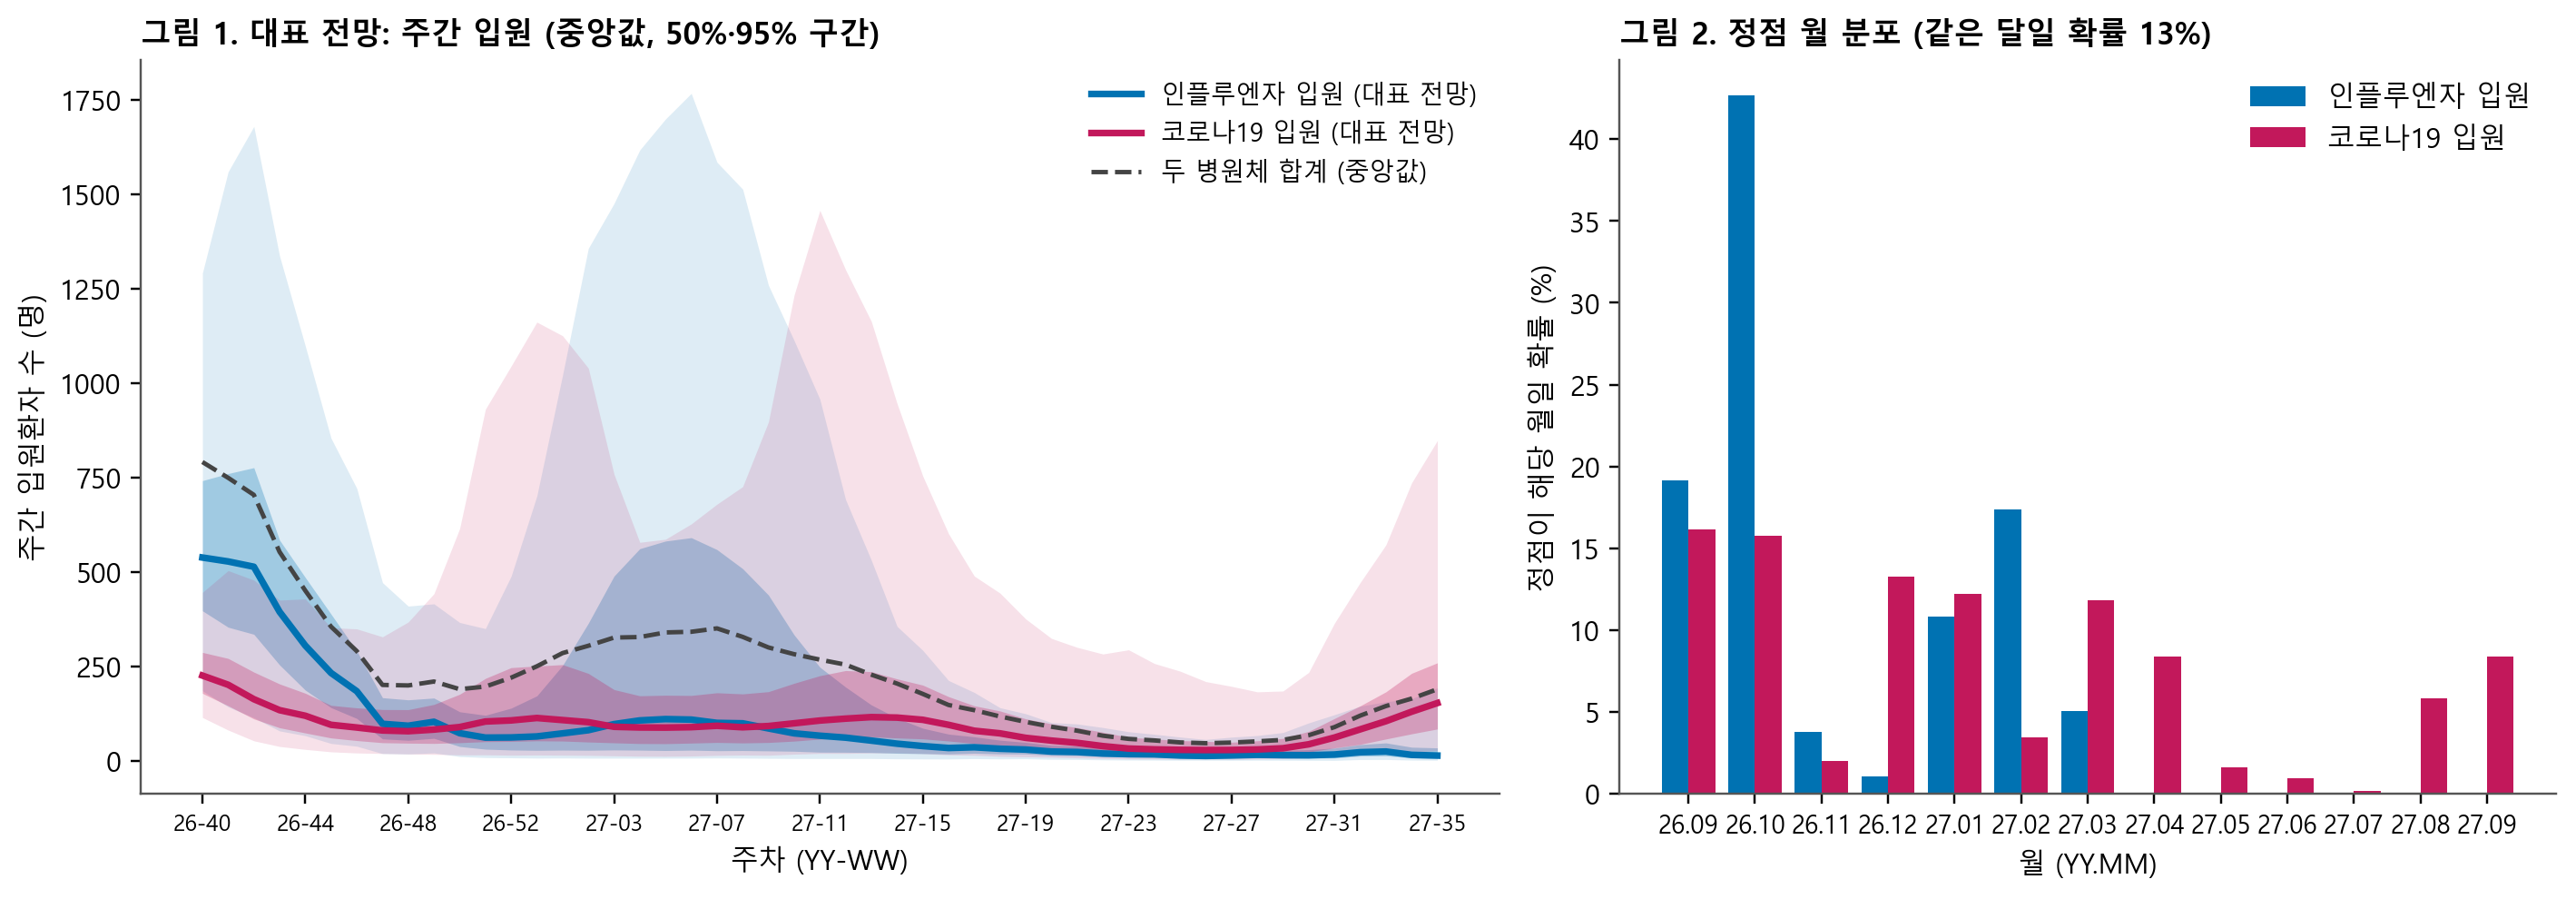

In [5]:
COL = {'flu': '#0072B2', 'cov': '#C2185B', 'sum': '#444444'}
x = np.arange(1, 50)
tick_i = list(range(0, 49, 4))


def band(ax, paths, c, lab):
    ax.fill_between(x, np.quantile(paths, 0.025, axis=0), np.quantile(paths, 0.975, axis=0), color=c, alpha=0.13, linewidth=0)
    ax.fill_between(x, np.quantile(paths, 0.25, axis=0), np.quantile(paths, 0.75, axis=0), color=c, alpha=0.28, linewidth=0)
    ax.plot(x, np.median(paths, axis=0), color=c, linewidth=2.4, label=lab)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={'width_ratios': [1.45, 1]})
ax = axes[0]
band(ax, hosp, COL['flu'], '인플루엔자 입원 (대표 전망)')
band(ax, cari, COL['cov'], '코로나19 입원 (대표 전망)')
ax.plot(x, np.median(tot, axis=0), color=COL['sum'], linewidth=1.6, linestyle='--', label='두 병원체 합계 (중앙값)')
ax.set_xticks([t + 1 for t in tick_i], [labels[t][2:] for t in tick_i], fontsize=8)
ax.set_xlabel('주차 (YY-WW)'); ax.set_ylabel('주간 입원환자 수 (명)')
ax.set_title('그림 1. 대표 전망: 주간 입원 (중앙값, 50%·95% 구간)', loc='left', fontweight='bold', fontsize=11)
ax.legend(frameon=False, loc='upper right', fontsize=9)
ax.grid(False)
ax = axes[1]
w = 0.4
xm = np.arange(len(month_names))
ax.bar(xm - w / 2, pf * 100, w, color=COL['flu'], label='인플루엔자 입원')
ax.bar(xm + w / 2, pc * 100, w, color=COL['cov'], label='코로나19 입원')
ax.set_xticks(xm, mlabel, rotation=0, fontsize=9)
ax.set_ylabel('정점이 해당 월일 확률 (%)'); ax.set_xlabel('월 (YY.MM)')
ax.set_title(f'그림 2. 정점 월 분포 (같은 달일 확률 {p_same_month * 100:.0f}%)', loc='left', fontweight='bold', fontsize=11)
ax.legend(frameon=False, fontsize=10)
# ax.grid(axis='x', visible=False)
ax.grid(False)
fig.tight_layout()
fig.savefig(OUT / 'brief_figure.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUT / 'brief_figure.png')))

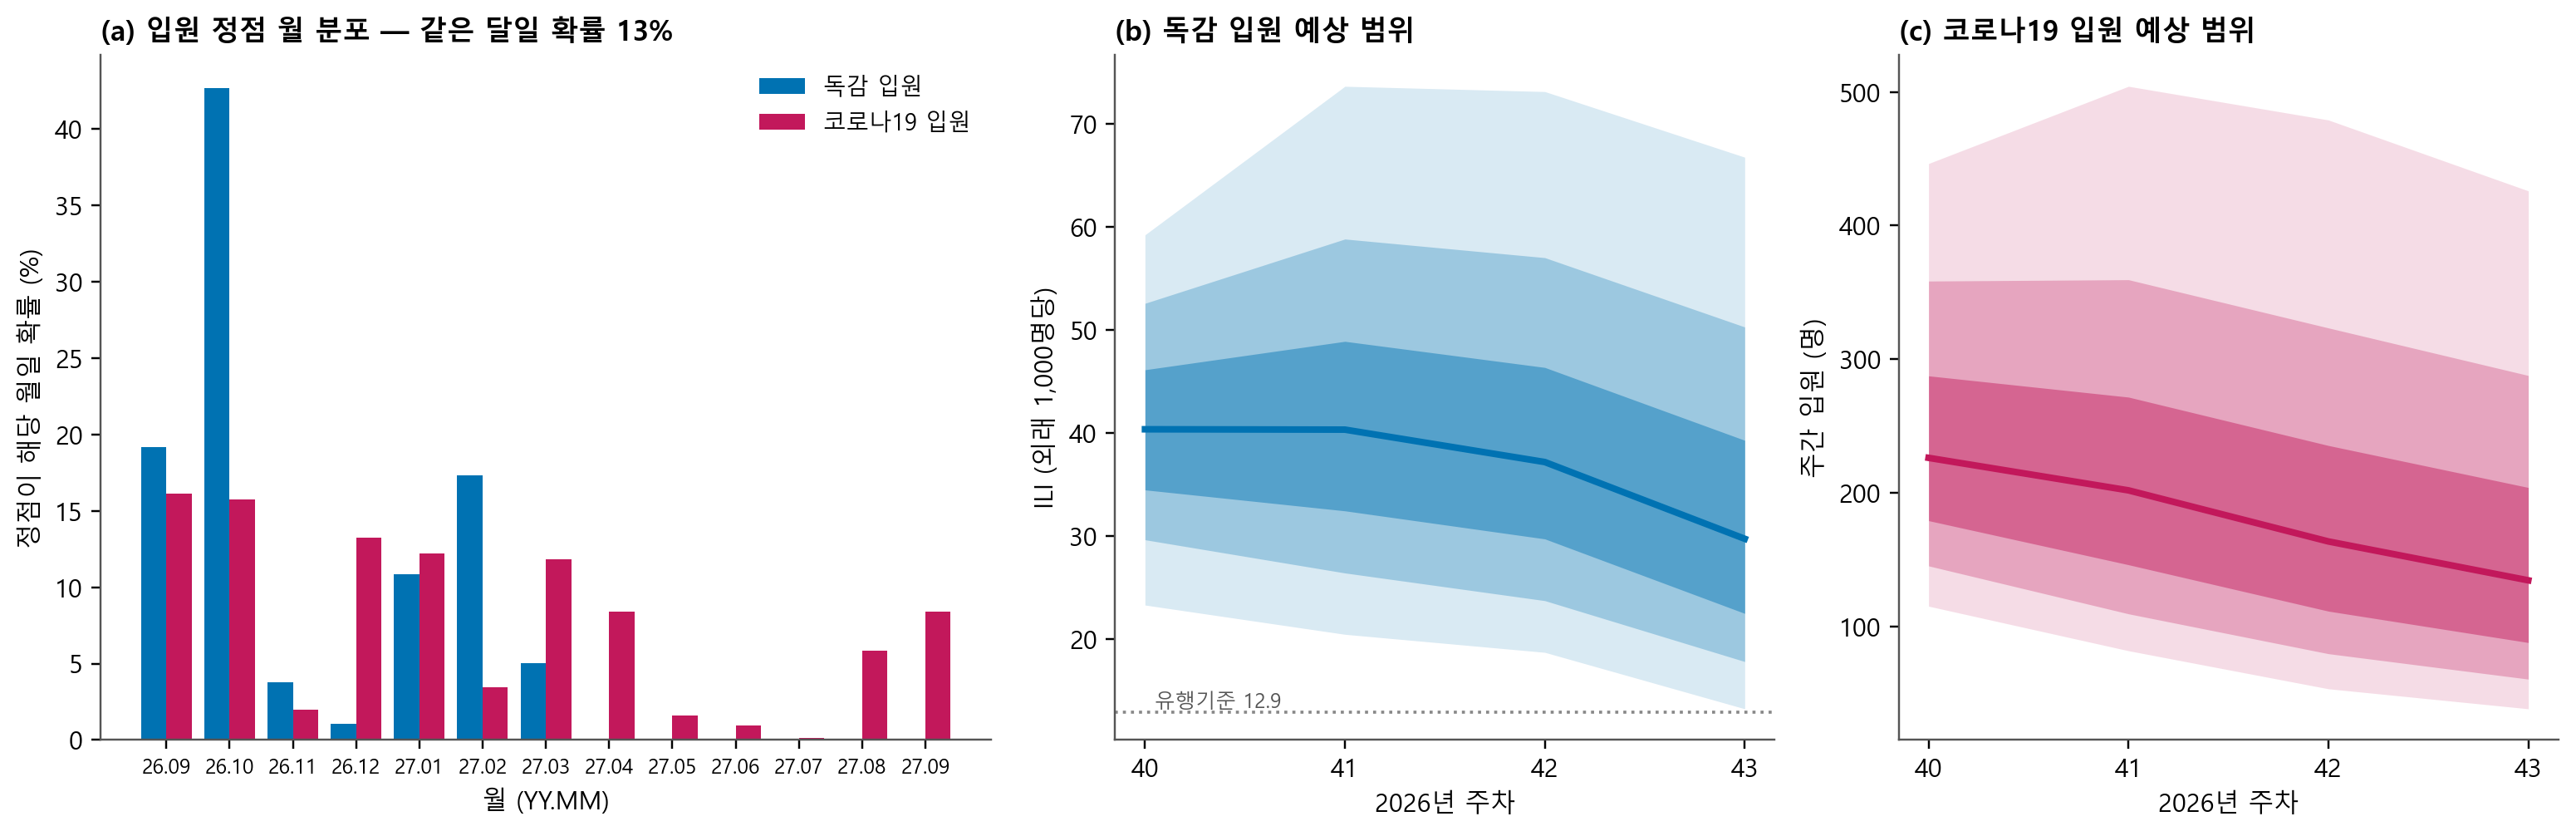

In [6]:
# ---- 정책 브리핑 1쪽용 그림: (a) 정점 월 분포, (b) ILI 판별 띠, (c) 코로나19 입원 판별 띠 (2026-40~43주) ----
# 위에서 만든 pf, pc, p_same_month, ili, cari, labels, month_names를 그대로 재사용합니다.
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.7), gridspec_kw={'width_ratios': [1.35, 1, 1]})

# (a) 정점이 해당 월일 확률
ax = axes[0]
w = 0.4
xm = np.arange(len(month_names))
ax.bar(xm - w / 2, pf * 100, w, color=COL['flu'], label='독감 입원')
ax.bar(xm + w / 2, pc * 100, w, color=COL['cov'], label='코로나19 입원')
ax.set_xticks(xm, mlabel, fontsize=8)
ax.set_xlabel('월 (YY.MM)'); ax.set_ylabel('정점이 해당 월일 확률 (%)')
ax.set_title(f'(a) 입원 정점 월 분포 — 같은 달일 확률 {p_same_month * 100:.0f}%', loc='left', fontweight='bold', fontsize=11)
ax.legend(frameon=False, fontsize=9); ax.grid(False)

# (b)(c) 판별 띠: 기점 직후 4주의 50·80·95% 분위수 띠와 중앙값
def judge_band(ax, paths, color, title, ylabel, threshold=None):
    wk = np.arange(40, 44)
    q = lambda p: np.quantile(paths[:, :4], p, axis=0)
    for lo, hi, a in [(0.025, 0.975, 0.15), (0.10, 0.90, 0.28), (0.25, 0.75, 0.45)]:
        ax.fill_between(wk, q(lo), q(hi), color=color, alpha=a, linewidth=0)
    ax.plot(wk, q(0.5), color=color, linewidth=2.6)
    if threshold is not None:
        ax.axhline(threshold, color='#888888', linestyle=':', linewidth=1.2)
        ax.text(40.05, threshold, f'유행기준 {threshold}', fontsize=8, color='#555555', va='bottom')
    ax.set_xticks(wk); ax.set_xlabel('2026년 주차'); ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left', fontweight='bold', fontsize=11); ax.grid(False)

judge_band(axes[1], ili, COL['flu'], '(b) 독감 입원 예상 범위', 'ILI (외래 1,000명당)', EPI_THRESHOLD)
judge_band(axes[2], cari, COL['cov'], '(c) 코로나19 입원 예상 범위', '주간 입원 (명)')
fig.tight_layout()
fig.savefig(OUT / 'brief_figure_abc.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUT / 'brief_figure_abc.png')))


## 5. 답안 제출 양식 채우기
노란 칸(분위수)만 채웁니다. 시트 3·4는 `ili`·`flu_hosp`(REP, F1, F2), `covid_ari`·`covid_sari`(REP, C1, C2)를 채웁니다(`covid_sari`는 선택 항목). 파일: `submission/submissoin_T01.xlsx`(저장 전에 `submission/previous_run/`에 백업을 만듭니다). 시트 1·2는 건드리지 않습니다. **엑셀에서 이 파일을 열어 둔 상태면 저장이 되지 않으니 닫고 실행하세요.**

In [7]:
all_ts = pd.concat([flu_ts, cov_ts], ignore_index=True)
all_single = pd.concat([flu_single, cov_single], ignore_index=True)
import shutil
from datetime import datetime
# 기준 파일: 제출 파일이 있으면 그것, 없으면 이름을 바꿔 둔 submissoin_T01_previous.xlsx. 둘 다 없을 때만 빈 양식에서 시작한다.
BASE_XLSX = next((q for q in [SUBMISSION_XLSX, OUT / 'submissoin_T01_previous.xlsx'] if q.exists()), None)
if BASE_XLSX is not None:
    (OUT / 'previous_run').mkdir(exist_ok=True)
    shutil.copy2(BASE_XLSX, OUT / 'previous_run' / f'submissoin_T01_백업_{datetime.now():%Y%m%d_%H%M%S}.xlsx')
    wb = openpyxl.load_workbook(BASE_XLSX)
    print('기준 파일:', BASE_XLSX.name)
else:
    wb = openpyxl.load_workbook(TEMPLATE)
    print('경고: 제출 파일이 없어 빈 양식에서 시작합니다. 시트 1·2(팀 정보, 문제 1)는 비어 있으니 직접 채워야 합니다.')

# --- 시트 3 ---
ws = wb['3.문제2_시계열']
hdr = {c.value: c.column for c in ws[1]}
key3 = {(r.target, r.scenario_id, int(r.week_index)): r for r in all_ts.itertuples(index=False)}
n3 = 0
for row in range(2, ws.max_row + 1):
    k = (ws.cell(row, hdr['target']).value, ws.cell(row, hdr['scenario_id']).value, ws.cell(row, hdr['week_index']).value)
    if k[0] is None or (k[0], k[1], k[2]) not in key3:
        continue
    src = key3[(k[0], k[1], int(k[2]))]
    assert src.target_week == ws.cell(row, hdr['target_week']).value, (k, src.target_week)
    for q in QCOLS:
        ws.cell(row, hdr[q]).value = round(float(getattr(src, q.replace('.', '_'), None) if False else all_ts.loc[(all_ts['target'] == k[0]) & (all_ts['scenario_id'] == k[1]) & (all_ts['week_index'] == k[2]), q].iloc[0]), 3)
    n3 += 1
print('시트 3 채운 행', n3)

# --- 시트 4 ---
ws = wb['4.문제2_단일값']
hdr = {c.value: c.column for c in ws[1]}
n4 = 0
for row in range(2, ws.max_row + 1):
    t, s = ws.cell(row, hdr['target']).value, ws.cell(row, hdr['scenario_id']).value
    m = all_single[(all_single['target'] == t) & (all_single['scenario_id'] == s)]
    if len(m) != 1:
        continue
    for q in QCOLS:
        v = float(m[q].iloc[0])
        ws.cell(row, hdr[q]).value = int(round(v)) if t.endswith('peak_week') else round(v, 2)
    n4 += 1
print('시트 4 채운 행', n4)

# --- 시트 1(팀정보)과 시트 2(문제 1)는 팀이 작성한 내용이므로 건드리지 않음 ---

# --- 시트 7 메타데이터 ---
w_f2 = flu_spec['REP']['w_F2']
if abs(w_f2 - 0.5) < 1e-9:
    flu_rep_text = f'인플루엔자 REP = F1·F2 경로를 그대로 합친 균등 혼합(각 1,000개, 가중치 정확히 F1 {1 - w_f2:.2f} : F2 {w_f2:.2f}). 가중치를 1/2로 둔 이유: 분기 조건(2026-48 이후 A(H3N2) 검출률)이 기점 2026-39에는 관측되지 않아 어느 시나리오가 더 유력하다는 정보가 없어 두 시나리오를 동등하게 가정하고, 근거 없이 정밀한 값을 쓰는 것을 피함.'
else:
    flu_rep_text = (f'인플루엔자 REP = F1·F2 경로 확률 혼합, F2 가중 {w_f2:.2f}: 이번 절기처럼 H1이 먼저 큰 파동을 만든 과거 절기({flu_spec["REP"]["seasons_used"]}) 중 '
                    f'A(H3N2) 20% 이상 절기 {len(flu_spec["REP"]["seasons_h3_ge_20pct"])}개를 라플라스 보정((k+1)/(n+2))해 설정.')
cp = cov_spec['params']
meta = {
    '모형 구조': '수준 모형 + AR(1) 오차. 인플루엔자: 그 주 검출률(전체·A(H1N1)pdm09·A(H3N2)·B; 현재·1주 전·3주 평균·로그)과 계절 주기로 log1p(ILI·ARI)를 설명(Ridge+ExtraTrees 평균). 코로나19: 월별 변이 점유율에서 만든 4개 지표(우세 계통 점유율·신규 계통 비중·4주/12주 교체 속도)와 계절 조화로 log1p(ARI)와 log1p(SARI)를 각각 설명(Ridge+ExtraTrees). 시나리오별 입력 경로 1,000개마다 AR(1) 오차 경로를 붙여 분위수 산출(코로나19는 기준모형 경로를 섞지 않음).',
    '추정 방법': f'실측치 적합(과거 자료). 수준 모형은 기점까지의 자료로 학습(인플루엔자는 코로나19 유행기 2020-10~2022-25 제외). 오차는 교차검증(인플루엔자: 절기 단위 leave-one-season-out, 코로나19: 26주 블록)에서 구해 AR(1) 계수를 추정. 인플루엔자의 혁신 크기와 모형은 롤링 백테스트 WIS로 선택. 코로나19의 AR(1) 장기 오차 크기(로그 척도 sd {cov_spec["sinf"]})와 모형은 롤링 백테스트 WIS로 선택(95% 구간 포함률 {cov_spec["backtest_cov95"]:.2f}, 부록 B 기준모형 대비 상대 WIS {cov_spec["backtest_relative_WIS"]:.2f}).',
    '입력 자료': '제공 자료만 사용: 인플루엔자 2차 학습 데이터_아형 검출률 추가(ILI·ARI·검출률 모두 2026-39까지, 결측 없음, 결측 대체 처리 없음), 코로나19 2차 학습 데이터(ARI·SARI), 2020-2026.8 변이 점유율(월별). 외부 설명변수 없음.',
    '기점 이후 정보 차단 방법': '모든 학습·검증·가중치 계산에서 기점(2026-39) 이후 자료를 쓰지 않음. 백테스트는 기점마다 자료를 잘라 학습하고, 이후 구간은 평가에만 사용.',
    '실행 방법': 'code/README_problem2.md 참고. 1) Problem2_influenza_scenarios.ipynb 실행(결과: influenza/results) 2) Problem2_covid_scenarios.ipynb 실행(결과: covid/results_v2) 3) Problem2_brief_and_submission.ipynb 실행(제출 엑셀 시트 3·4·7·8 갱신). 노트북은 README의 폴더 구성에 맞춰 두고 실행. Python 3.13, pandas, scikit-learn, openpyxl, matplotlib. 난수 씨앗 고정.',
    '1-나 → 1-다 변경 기록': '해당 없음 (문제 2 제출분).',
    '대표 전망의 시나리오 가중치': flu_rep_text + f' 코로나19 REP = C1·C2 경로를 그대로 합친 균등 혼합(각 1,000개, 가중치 정확히 C1 {1 - cov_spec["w_C2_in_REP"]:.2f} : C2 {cov_spec["w_C2_in_REP"]:.2f}). 인플루엔자와 같은 1/2 : 1/2 균등이며, 신규 변이 우세화(C2)의 발생 시점·여부를 기점에서 판단할 근거가 없어 동등하게 가정. covid_sari도 같은 방식.',
    '공통 시나리오 근사 방법': ('인플루엔자: 시나리오 검출률(A(H1N1)pdm09·A(H3N2)·B)을 모형 입력으로 직접 지정. F1은 예측 각 주의 1년 전→2년 전 같은 주차 A(H3N2)+B 합이 5% 미만이면 그 값, 둘 다 5% 이상이면 배경 수준으로 대체. F2는 2026-48±2주에 2025-26절기 A(H3N2) 곡선 적용. '
                         f'코로나19: 변이 점유율 경로를 모형 입력으로 지정. C1(신규 변이 없음)은 과거 우세 변이 10개가 신규 변이 도착(단일 신규 계통 20% 이상) 전에 보인 점유율 비율 곡선을 PQ.16.1.1(53.9%)에 곱하고 도착 이후는 마지막 비율 유지, 곡선 1,000개(시점 ±{cp["TIMING_JITTER"]}주, 곡선 오차 {100 * cp["CURVE_NOISE"]:.0f}%). '
                         f'C2는 신규 변이가 2026-50±2주에 점유율 50%에 도달(과거 교체 5건의 월 로짓 기울기 중앙값 {cp["C2_SLOPE_PER_MONTH"]:.2f}, 정점 {100 * cp["C2_PEAK"]:.1f}%)하고 정점 이후는 과거 우세 변이의 감소 곡선을 따라 감소(줄어든 몫은 후속 변이). 중화항체 40% 이상 저하는 별도 승수 없이 과거 우세화와 같은 속도의 교체로 근사.'),
    '가장 불안한 가정 하나': '시나리오 검출률·점유율 경로가 맞다는 것. 인플루엔자는 H1 파동 모양(과거 4개 파동 평균), 코로나19는 과거 우세 변이 10개의 패턴(자연 구간 0~5개월, 정점 후 감소 속도가 계통마다 다름). 백테스트는 실제 입력을 조건으로 한 값이라 입력 오차는 반영하지 않음.',
    '대형언어모형 사용 범위': '코드 작성·실행, 자료 점검, 분석 보조, 문서 초안 작성(Claude Code). 모형 선택과 가정은 사람이 검토해야 하며 결과 해석의 책임은 제출팀에 있음.',
    '한계': '코로나19 자료가 143주(2024-01~)뿐이라 학습 정보가 적고 입원 모형 오차가 큼(95% 구간 상단이 중앙값의 약 5~12배). 코로나19 9월 이후 점유율은 자료가 없어 2026-08 값(53.9%)이 기점까지 유지된다고 가정. 인플루엔자 입원(ARI)은 ILI와 같은 검출률 경로를 쓰되 별도 백테스트 없이 ILI에서 고른 모형을 적용. 코로나19 SARI(선택 항목)도 ARI 백테스트에서 고른 모형·오차 크기를 그대로 쓰며 SARI 자체의 백테스트는 하지 않음. 두 병원체 경로는 독립 가정(동시 정점 확률은 상관 구조 미반영).',
}
ws = wb['7.메타데이터']
for row in range(2, ws.max_row + 1):
    k = ws.cell(row, 1).value
    if k in meta:
        ws.cell(row, 2).value = meta[k]
        ws.cell(row, 2).alignment = Alignment(wrap_text=True, vertical='top')

# --- 정책 브리핑 시트 ---
thin = Side(style='thin', color='BBBBBB')
if '8.정책브리핑(brief_2)' in wb.sheetnames:
    del wb['8.정책브리핑(brief_2)']
bs = wb.create_sheet('8.정책브리핑(brief_2)')
bs.sheet_view.showGridLines = False
for col, wd in zip('ABCDEFGH', [14, 14, 14, 14, 14, 14, 14, 14]):
    bs.column_dimensions[col].width = wd
f_h = Font(name='Malgun Gothic', size=14, bold=True, color='1F3A5F')
f_s = Font(name='Malgun Gothic', size=10.5, bold=True, color='FFFFFF')
f_b = Font(name='Malgun Gothic', size=10)
fill_s = PatternFill('solid', fgColor='1F4E9C')
row_i = 1


def put_text(text, font=f_b, height=None, fill=None, merge=True):
    global row_i
    bs.merge_cells(start_row=row_i, start_column=1, end_row=row_i, end_column=8)
    c = bs.cell(row_i, 1, text)
    c.font, c.alignment = font, Alignment(wrap_text=True, vertical='top')
    if fill:
        c.fill = fill
    bs.row_dimensions[row_i].height = height or max(16, 14 * (len(text) // 62 + 1 + text.count('\n')))
    row_i += 1


def section(title):
    put_text(title, f_s, 18, fill_s)


mn = lambda mm: f'{mm[0]}년 {mm[1]}월'
q50_tot, q025_tot, q975_tot = tot_q[3], tot_q[0], tot_q[6]
ili_med_peak = float(np.median(ili.max(axis=1)))
f1_pk = labels[int(np.median(flu['flu_hosp_F1'].argmax(axis=1)))]
f2_pk = labels[int(np.median(flu['flu_hosp_F2'].argmax(axis=1)))]
cov_early = float((cari.argmax(axis=1) <= 2).mean())
flu_peak_med = float(np.median(hosp.max(axis=1)))
cov_peak_med = float(np.median(cari.max(axis=1)))
ili_s = qb_ili.loc['4주 합계']
cov_s = qb_cov.loc['4주 합계']

put_text('2026-27절기 인플루엔자·코로나19 입원 중장기 전망과 대응 시점 (정책 브리핑 1쪽)', f_h, 26)
put_text('작성: 질병관리청 감염병 분석 담당 | 작성일 2026-10-01 | 기점 2026-39, 전망 2026-40 ~ 2027-35 (49주) | 300개소 표본감시 기준 | 팀: ______', f_b, 18)
section('요약 (3줄)')
put_text(f'1. 인플루엔자 입원 정점은 현재 A(H1N1)pdm09 파동이 이끄는 F1에서 {f1_pk}주 전후(중앙값), 겨울 A(H3N2) 유입 F2에서는 {f2_pk}주 전후입니다. 대표 전망의 입원 정점 중앙값은 인플루엔자 {flu_peak_med:,.0f}명, 코로나19 {cov_peak_med:,.0f}명입니다.\n'
         f'2. 두 병원체의 입원 정점이 같은 달일 확률은 {p_same_month * 100:.0f}%이고 입원 합계 정점은 중앙값 {q50_tot:,.0f}명(95% 구간 {q025_tot:,.0f}~{q975_tot:,.0f})입니다.\n'
         f'3. 2026-40~43주 관측이 아래 판별 범위를 벗어나면 대표 전망을 바꿉니다. 내년 여름(2027-27~35주) 유행기준 재초과 확률은 약 {p_final * 100:.0f}%입니다.', f_b, 92)
section('그림')
fig_row = row_i
bs.add_image(XLImage(str(OUT / 'brief_figure.png')), f'A{fig_row}')
img = bs._images[-1]
img.width, img.height = 740, int(740 * 4.6 / 13 * 1.0) + 10
for r in range(fig_row, fig_row + 14):
    bs.row_dimensions[r].height = 18
row_i = fig_row + 14
section('Q-a 동시 정점')
put_text(f'· 같은 달 확률 {p_same_month * 100:.0f}% (±2주 이내 {p_within2 * 100:.0f}%). 인플루엔자 입원 정점은 {mn(top_f)}이 가장 유력하며({pf.max() * 100:.0f}%), 코로나19 입원 정점은 {mn(top_c)}이 가장 유력합니다({pc.max() * 100:.0f}%).\n'
         f'· 해석 주의: 코로나19 입원은 2026-38주(337명)에 이미 정점을 지나 전망 창의 정점이 첫 3주(2026-40~42)에 몰립니다({cov_early * 100:.0f}%). 이는 올해 여름 파동의 하강기이며, 그 이후의 정점은 {mn(second_c)}이 가장 유력합니다({second_p * 100:.0f}%).\n'
         f'· 시나리오 조합별 같은 달 확률: ' + ', '.join(f'{k} {v * 100:.0f}%' for k, v in combo.items()) + '.\n'
         f'· 두 병원체 입원 합계의 정점 규모: 중앙값 {q50_tot:,.0f}명, 50% 구간 {tot_q[2]:,.0f}~{tot_q[4]:,.0f}명, 95% 구간 {q025_tot:,.0f}~{q975_tot:,.0f}명.\n'
         '· 가정: 두 병원체 경로는 독립(공통 접촉 지수 미반영). 상관이 양이면 같은 달 확률은 더 커집니다. 의미: 인플루엔자 정점기에 코로나19 입원이 겹치면 병상 압력은 합계 기준으로 점검해야 합니다.', f_b, 132)
section('Q-b 판별 규칙 (2026-40 ~ 43주 관측)')
rows_b = []
for name, tab, unit in [('ILI', qb_ili, ''), ('코로나19 입원(ARI)', qb_cov, '명')]:
    lo80, hi80, lo95, hi95 = tab.loc['4주 합계', 'q0.10'], tab.loc['4주 합계', 'q0.90'], tab.loc['4주 합계', 'q0.025'], tab.loc['4주 합계', 'q0.975']
    w1 = tab.iloc[0]
    rows_b.append(f'· {name}: 유지 = 4주 합계가 {lo80:,.0f}~{hi80:,.0f}{unit} 안(주별로는 80% 구간 안, 예: 40주 {w1["q0.10"]:,.0f}~{w1["q0.90"]:,.0f}). 버림 = 4주 합계가 {lo95:,.0f}{unit} 미만 또는 {hi95:,.0f}{unit} 초과, 또는 4주 중 2주 이상이 95% 구간({w1["q0.025"]:,.0f}~{w1["q0.975"]:,.0f}, 40주 기준) 밖. 그 사이는 보류하고 시나리오 가중치만 조정.')
put_text('\n'.join(rows_b) + '\n'
         '· 버릴 때 먼저 고칠 것: ① ILI가 상한 밖이면 A(H3N2) 검출률이 앞당겨 오르는지 확인하고 F2 가중치를 올림, 하한 밖이면 H1 파동이 일찍 꺾인 것이므로 H1 곡선 모양(유사 파동 선택)을 고침. '
         '② 코로나19가 상한 밖이면 월별 점유율에서 단일 신규 계통이 20% 이상 올라오는지 확인해 C2(신규 변이 우세화) 결과를 참고하고, 하한 밖이면 PQ.16.1.1이 유지되는지(C1)와 계절 요인을 점검. ③ ILI 대비 인플루엔자 입원 비율이 어긋나면 ILI→입원 연결을 고침.', f_b, 150)
section('Q-c 내년 여름')
put_text(f'· 2027-27~35주에 ILI가 유행기준({EPI_THRESHOLD})을 한 번이라도 넘을 확률은 약 {p_final * 100:.0f}%입니다. 근거: 모형 조건부 {p_model * 100:.0f}% (대표 전망 경로의 비율, 시나리오가 여름 검출률을 거의 0으로 두므로 하한) 와 과거 빈도 {p_hist * 100:.0f}% (코로나19 유행기 제외 {len(hist_df)}개 해 중 {int(hist_df["유행기준 초과"].sum())}개 해, 올해 포함)의 평균.\n'
         '· 올해 여름 H1 파동이 2026-35주 전후에 시작된 점을 고려하면 내년에도 이른 시작 가능성이 있어 과거 빈도 쪽이 더 현실적일 수 있습니다. 2027년 6월 이후 A(H1N1)pdm09 검출률이 5%를 넘으면 확률을 상향합니다.', f_b, 78)
section('가장 불안한 가정 하나')
put_text('시나리오 검출률·변이 점유율 경로가 맞다는 가정. 입원 전망은 검출률(인플루엔자)과 변이 점유율(코로나19)이 정해 주는 경로에 크게 의존하는데, 이번 H1 파동의 곡선은 과거 4개 파동 평균이고, 코로나19는 과거 우세 변이 10개의 점유율 패턴을 현재 PQ.16.1.1에 적용한 것입니다.', f_b, 52)
section('다음 갱신 시점과 살필 지표')
put_text('· 2026-10-15 (2026-41주 자료): ILI·인플루엔자 입원, 소분류 검출률(특히 A(H3N2) ≥ 5% 여부). · 2026-10-29 (2026-43주 자료): Q-b 판별 규칙 적용. · 월별 코로나19 변이 점유율에서 단일 신규 계통이 20%를 넘는지(과거 사례에서 그 뒤 약 2개월 내 우세화). · 연휴 주(2026-39 추석, 2027-06 설)는 외래 분모 감소로 ILI가 높게 나올 수 있어 해석 시 보정.', f_b, 78)

out_xlsx = SUBMISSION_XLSX
try:
    wb.save(out_xlsx)
except PermissionError:
    raise SystemExit(f'{out_xlsx} 저장 실패: 엑셀에서 파일을 열어 두었으면 닫고 다시 실행하세요.')
print('저장:', out_xlsx.resolve())

# --- 검증: 단조성·음수·결측 ---
chk = openpyxl.load_workbook(out_xlsx)
for name in ['3.문제2_시계열']:
    ws = chk[name]
    hdr = {c.value: c.column for c in ws[1]}
    bad = filled = 0
    for row in range(2, ws.max_row + 1):
        vals = [ws.cell(row, hdr[q]).value for q in QCOLS]
        if all(v is None for v in vals):
            continue
        filled += 1
        if any(v is None for v in vals) or any(v < 0 for v in vals) or any(b < a for a, b in zip(vals, vals[1:])):
            bad += 1
    print(name, '채운 행', filled, '형식 오류', bad)
ws = chk['4.문제2_단일값']
hdr = {c.value: c.column for c in ws[1]}
bad = filled = 0
for row in range(2, ws.max_row + 1):
    vals = [ws.cell(row, hdr[q]).value for q in QCOLS]
    if all(v is None for v in vals):
        continue
    filled += 1
    bad += int(any(v is None or v < 0 for v in vals) or any(b < a for a, b in zip(vals, vals[1:])))
print('4.문제2_단일값 채운 행', filled, '형식 오류', bad)

기준 파일: submissoin_T01.xlsx


시트 3 채운 행 588
시트 4 채운 행 36


저장: D:\Dropbox\Jihyeon\MSOL_research\2609_Forecast_workshop\Code\Q2_ensemble\submission\submissoin_T01.xlsx
3.문제2_시계열 채운 행 588 형식 오류 0
4.문제2_단일값 채운 행 36 형식 오류 0


## 6. 대표 결과: 두 시나리오 1/2 균등 혼합 (ILI, 코로나19 ARI)
- 각 질병의 두 시나리오(ILI: F1·F2, 코로나19 ARI: C1·C2)를 **1/2 : 1/2**로 섞습니다. 시나리오마다 경로가 1,000개로 같으므로 두 시나리오의 경로를 모두 합치면(2,000개) 각 시나리오의 가중치가 정확히 1/2씩입니다. 분위수·정점·누적은 합친 경로에서 직접 계산합니다.
- 그림은 **1×2 한 장**(왼쪽 ILI, 오른쪽 코로나19 ARI)으로 `submission/representative_equal_1x2.png`에 저장합니다. 한 그래프 안에 혼합 결과(중앙값과 50%·95% 구간)를 그렸고(시나리오별 중앙값 점선은 그리지 않음) 눈금선(grid)은 없앴습니다.
- 엑셀(시트 3·4)의 REP도 이 혼합과 같은 값입니다(두 시나리오의 경로를 그대로 합친 것). 그래서 REP 그래프를 따로 그리지 않습니다.

,target,scenario_id,q0.025,q0.10,q0.25,q0.50,q0.75,q0.90,q0.975
0,ILI_peak_week,EQUAL,1.0,1.0,2.0,3.0,18.0,21.0,23.0
1,ILI_peak_value,EQUAL,28.7,36.2,43.5,53.7,68.9,88.0,115.7
2,ILI_cum_total,EQUAL,336.3,396.0,473.8,652.2,945.3,1149.6,1357.7
3,covid_ari_peak_week,EQUAL,1.0,1.0,3.0,15.0,28.0,48.0,49.0
4,covid_ari_peak_value,EQUAL,163.6,223.3,296.8,455.4,774.5,1347.5,2492.1
5,covid_ari_cum_total,EQUAL,2127.3,2889.6,3954.7,5841.5,8586.9,12358.1,19586.8


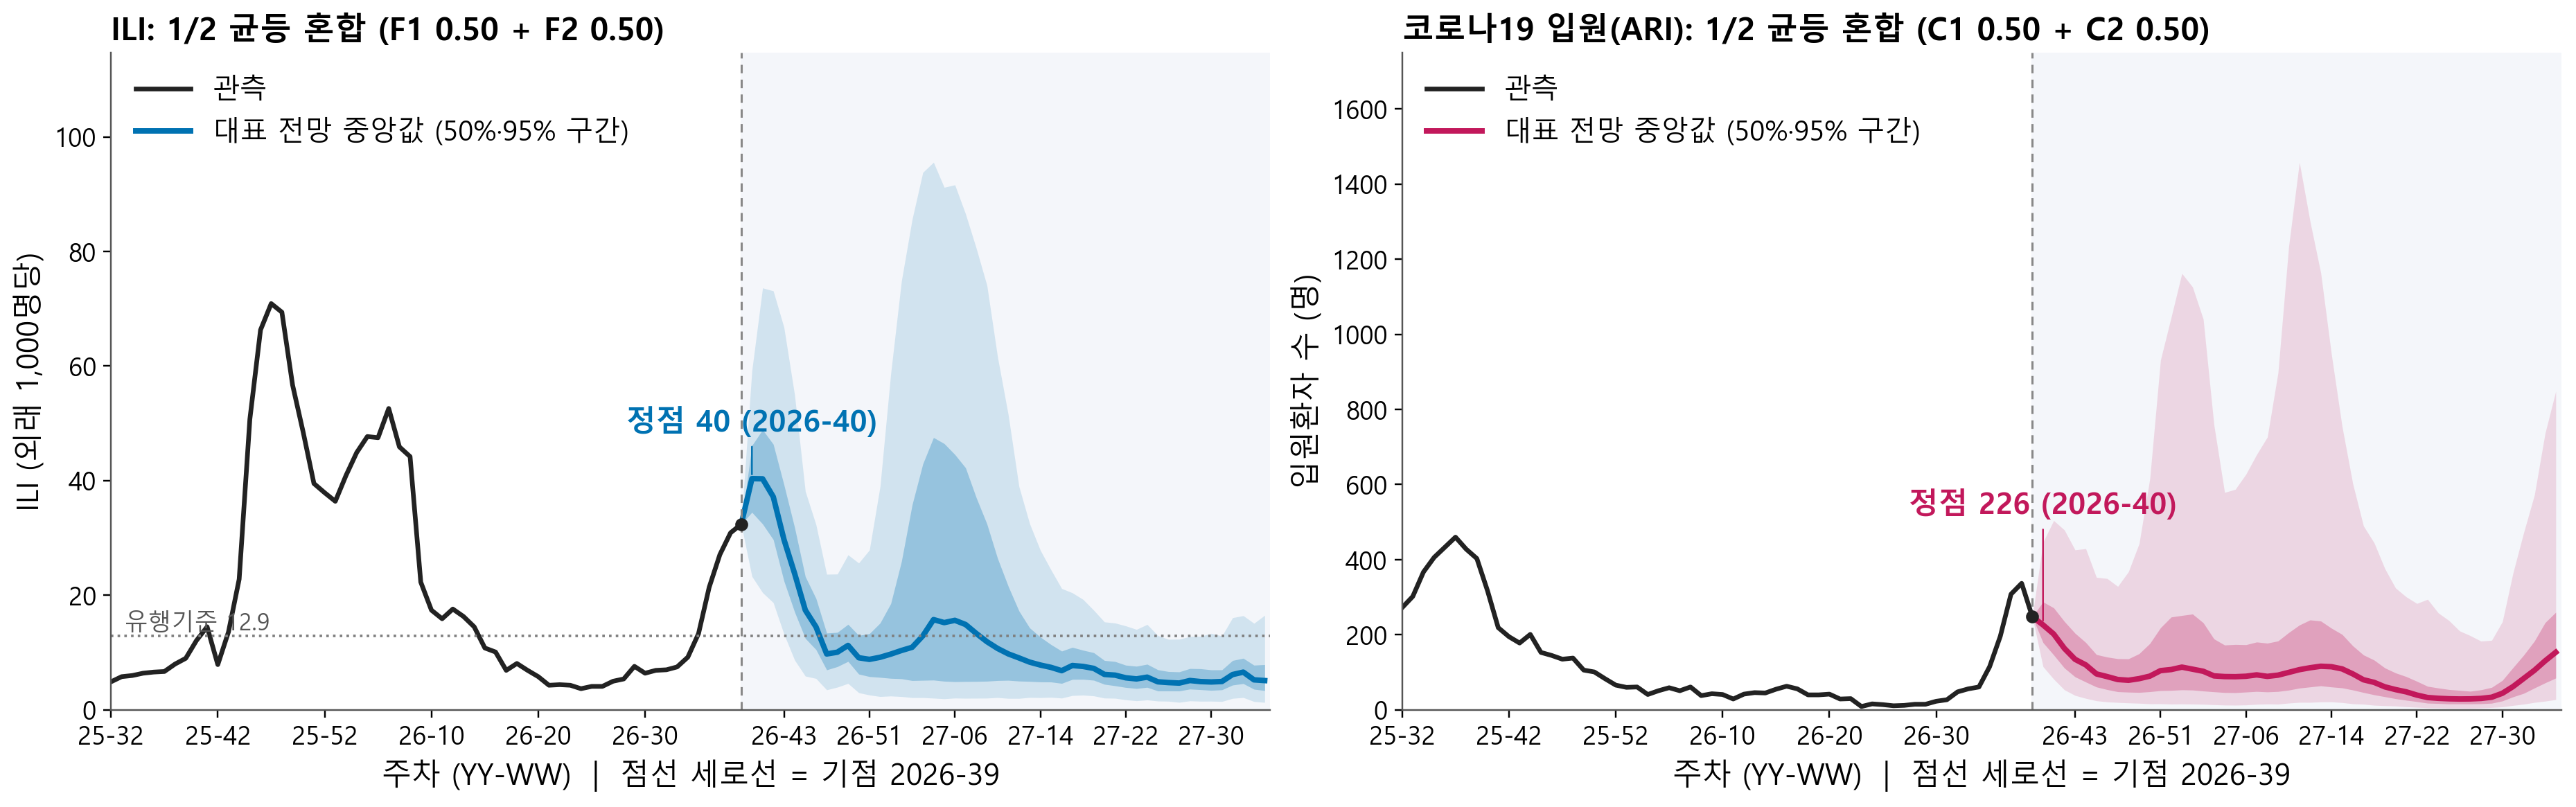

저장: ['representative_equal_1x2.png', 'representative_equal_quantiles.csv', 'representative_equal_single_values.csv']


In [8]:
HIST_N = 60
flu_obs = pd.read_excel('influenza/인플루엔자 2차 학습 데이터_아형 검출률 추가.xlsx').sort_values('년주')
cov_obs = pd.read_excel('covid/코로나19 2차 학습 데이터.xlsx')
cov_obs.columns = ['년도', '주차', '년주', 'ARI', 'SARI']
cov_obs = cov_obs.sort_values('년주')

TARGETS = {
    'ILI': {'name': 'ILI', 'ylabel': 'ILI (외래 1,000명당)', 'comp': {'F1': flu['ili_F1'], 'F2': flu['ili_F2']},
            'obs': flu_obs['ILI'].to_numpy(float), 'obs_w': flu_obs['년주'].to_numpy(int), 'color': '#0072B2', 'threshold': EPI_THRESHOLD, 'peak_up': 1.18},
    'covid_ari': {'name': '코로나19 입원(ARI)', 'ylabel': '입원환자 수 (명)', 'comp': {'C1': cov['covid_ari_C1'], 'C2': cov['covid_ari_C2']},
                  'obs': cov_obs['ARI'].to_numpy(float), 'obs_w': cov_obs['년주'].to_numpy(int), 'color': '#C2185B', 'threshold': None, 'peak_up': 2.3},
}
COMP_COLORS = {'F1': '#1F4E9C', 'F2': '#C2185B', 'C1': '#1F4E9C', 'C2': '#C2185B'}
fut_lab = [f'{l[2:4]}-{l[5:]}' for l in labels]

# 1/2 균등 혼합: 두 시나리오 경로를 그대로 합침(각 1,000개 -> 가중치 1/2씩)
quant_rows, single_rows = [], []
for key, t in TARGETS.items():
    arrs = list(t['comp'].values())
    assert all(len(a) == len(arrs[0]) for a in arrs)
    t['equal'] = np.concatenate(arrs, axis=0)
    q = np.maximum.accumulate(np.quantile(t['equal'], QUANTILES, axis=0).T, axis=1)
    for k in range(49):
        quant_rows.append({'target': key, 'scenario_id': 'EQUAL', 'week_index': k + 1, 'target_week': labels[k], **dict(zip(QCOLS, q[k]))})
    for nm, vals, method in [('peak_week', t['equal'].argmax(axis=1) + 1.0, 'nearest'), ('peak_value', t['equal'].max(axis=1), 'linear'), ('cum_total', t['equal'].sum(axis=1), 'linear')]:
        single_rows.append({'target': f'{key}_{nm}', 'scenario_id': 'EQUAL', **dict(zip(QCOLS, np.quantile(vals, QUANTILES, method=method)))})
pd.DataFrame(quant_rows).to_csv(OUT / 'representative_equal_quantiles.csv', index=False)
single_df = pd.DataFrame(single_rows)
single_df.to_csv(OUT / 'representative_equal_single_values.csv', index=False)
display(single_df.round(1))


def draw_panel(ax, t, paths, title):
    obs = t['obs'][-HIST_N:]
    yw = t['obs_w'][-HIST_N:]
    x_hist = np.arange(-len(obs) + 1, 1)
    x_fut = np.arange(1, 50)
    hist_lab = [f'{int(v) // 100 % 100}-{int(v) % 100:02d}' for v in yw]
    c = t['color']
    x = np.r_[0, x_fut]
    last = obs[-1]
    ax.axvspan(0, 49.5, color='#F4F6FA', zorder=0)
    ax.plot(x_hist, obs, color='#222222', linewidth=2.2, label='관측')
    for lo, hi, a in [(0.025, 0.975, 0.14), (0.25, 0.75, 0.28)]:
        ax.fill_between(x, np.r_[last, np.quantile(paths, lo, axis=0)], np.r_[last, np.quantile(paths, hi, axis=0)], color=c, alpha=a, linewidth=0)
    ax.plot(x, np.r_[last, np.median(paths, axis=0)], color=c, linewidth=2.6, label='대표 전망 중앙값 (50%·95% 구간)')
    ax.scatter([0], [last], color='#222222', s=26, zorder=5)
    ax.axvline(0, color='#888888', linewidth=1.0, linestyle=(0, (4, 3)))
    if t['threshold']:
        ax.axhline(t['threshold'], color='#7F7F7F', linestyle=':', linewidth=1.2)
        ax.text(-len(obs) + 1.5, t['threshold'], f' 유행기준 {t["threshold"]}', va='bottom', fontsize=11, color='#555555')
    med = np.median(paths, axis=0)
    pk = int(np.argmax(med))
    ax.annotate(f'정점 {med[pk]:.0f} ({labels[pk]})', xy=(pk + 1, med[pk]), xytext=(pk + 1, med[pk] * t['peak_up'] + 1), ha='center', fontsize=14, color=c, fontweight='bold', arrowprops=dict(arrowstyle='-', color=c, lw=0.8))
    ticks = list(range(-len(obs) + 1, 1, 10)) + list(range(4, 50, 8))
    ax.set_xticks(ticks, [hist_lab[tk + len(obs) - 1] if tk <= 0 else fut_lab[tk - 1] for tk in ticks], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlim(-len(obs) + 1, 49.5)
    ax.set_ylim(0, max(float(np.quantile(paths, 0.975, axis=0).max()), float(obs.max())) * 1.2)
    ax.set_xlabel('주차 (YY-WW)  |  점선 세로선 = 기점 2026-39', fontsize=14)
    ax.set_ylabel(t['ylabel'], fontsize=14)
    ax.set_title(title, loc='left', fontsize=15, fontweight='bold')
    ax.grid(False)
    ax.legend(frameon=False, loc='upper left', fontsize=13)


# 1x2 (왼쪽 ILI, 오른쪽 코로나19 ARI): 두 시나리오 1/2 균등 혼합
fig, axes = plt.subplots(1, 2, figsize=(17, 5.4))
for ax, (key, t) in zip(axes, TARGETS.items()):
    names = list(t['comp'])
    draw_panel(ax, t, t['equal'], f'{t["name"]}: 1/2 균등 혼합 ({names[0]} 0.50 + {names[1]} 0.50)')
fig.tight_layout()
fig.savefig(OUT / 'representative_equal_1x2.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUT / 'representative_equal_1x2.png')))
print('저장:', [p.name for p in sorted(OUT.glob('representative_*'))])
